<a href="https://colab.research.google.com/github/mirrash7/Experiments/blob/main/sam3d_pitch_scene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAM 3D Body — players to a 3D pitch scene

One linear pipeline:
0. **Setup** (run once) → 1. **Load model** → 2. **Detect** → 3. **Select players** → 4. **Pitch homography** → 5. **Reconstruct selected** → 6. **Place in a 3D scene**

Sections 0–1 are run-once per Colab session. Use a GPU runtime (**Runtime → Change runtime type → GPU**).

## 0. One-time setup

In [1]:
!nvidia-smi -L
%cd /content
![ -d sam-3d-body ] || git clone https://github.com/facebookresearch/sam-3d-body.git
%cd /content/sam-3d-body

!pip install -q \
  pytorch-lightning pyrender opencv-python yacs scikit-image einops timm dill \
  pandas rich hydra-core hydra-submitit-launcher hydra-colorlog pyrootutils \
  webdataset chump 'networkx==3.2.1' roma joblib seaborn wandb appdirs \
  cython jsonlines pytest xtcocotools loguru optree fvcore black \
  pycocotools tensorboard huggingface_hub trimesh plotly
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git@a1ce2f9' --no-build-isolation --no-deps
!pip install -q 'git+https://github.com/microsoft/MoGe.git'

GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-831dd63d-d7c3-f977-77fa-f9e5abe0a884)
/content
Cloning into 'sam-3d-body'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 184 (delta 38), reused 14 (delta 14), pack-reused 70 (from 1)
Receiving objects: 100% (184/184), 22.39 MiB | 19.20 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/sam-3d-body
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.

In [2]:
# Authenticate for the gated checkpoint (paste a read-scoped HF token)
from huggingface_hub import login
login()

## 1. Load model (memory-clean)

`setup_sam_3d_body` pulls the checkpoint from HF and wires up the ViTDet detector + MoGe2 FOV estimator. The env vars below set headless rendering and reduce VRAM fragmentation.

In [3]:
import os
os.environ['PYOPENGL_PLATFORM'] = 'egl'                       # headless render
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc, torch
gc.collect(); torch.cuda.empty_cache()
print('free/total GPU bytes:', torch.cuda.mem_get_info())

%cd /content/sam-3d-body
import cv2, numpy as np
from notebook.utils import setup_sam_3d_body
from tools.vis_utils import visualize_sample_together

estimator = setup_sam_3d_body(hf_repo_id='facebook/sam-3d-body-dinov3')
FACES = np.asarray(estimator.faces)
print('Model ready. faces:', FACES.shape)

free/total GPU bytes: (84646100992, 85094825984)
/content/sam-3d-body


/content/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...
Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip


...

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
model_final_f05665.pkl: 2.77GB [00:08, 330MB/s]                            


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...


model.pt:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓
Model ready. faces: (36874, 3)


## 2. Detect

Point at your image. `process_one_image` returns one dict per detected person (each has `bbox`, `pred_vertices`, `pred_keypoints_2d`, `focal_length`, ...).

In [7]:
IMAGE_PATH = '/content/Crop.png'   # <-- your image
OUT_DIR = '/content/scene_out'; os.makedirs(OUT_DIR, exist_ok=True)

img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f'Could not read {IMAGE_PATH}'
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

all_people = estimator.process_one_image(img_rgb, bbox_thr=0.3)
print(f'Detected {len(all_people)} people')

####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[1.2057692e-01 3.9421310e+02 2.6742193e+01 4.7564316e+02]
 [4.8886322e+01 2.5297179e+02 7.4553131e+01 3.2762070e+02]
 [4.9467216e+01 3.9879996e+02 7.5438408e+01 4.5626288e+02]
 [6.4260536e+01 3.0800452e+02 9.0958687e+01 3.6425159e+02]
 [1.5243166e+02 1.7888113e+02 1.8120747e+02 2.5392694e+02]
 [2.3340639e+02 4.9505206e+02 2.7248361e+02 5.9202826e+02]
 [7.5953290e+02 8.8985146e+01 7.7850592e+02 1.2875647e+02]
 [7.8936060e+02 8.9266724e+01 8.0841833e+02 1.2995029e+02]
 [9.7755603e+02 7.2637482e+02 1.0517867e+03 8.1258191e+02]
 [9.7913007e+02 9.4972137e+01 1.0036886e+03 1.3141597e+02]
 [1.0512125e+03 6.4454468e+02 1.0909084e+03 7.2679553e+02]
 [1.0590824e+03 5.9177313e+02 1.0964274e+03 6.6211975e+02]
 [1.0702743e+03 5.0274686e+02 1.0930212e+03 5.4827936e+02]
 [1.0762018e+03 6.2089789e+02 1.1175535e+03 6.7063104e+02]
 [1.0789781e+03 5.7294470e+02 1.1190317e+03 6.2742975e+02]
 [1.0796521e+03 6

## 3. Select players

Indexed overlay + thumbnails to identify people, then checkboxes. (Fallback: set `SELECTED_IDXS = [...]` manually.)

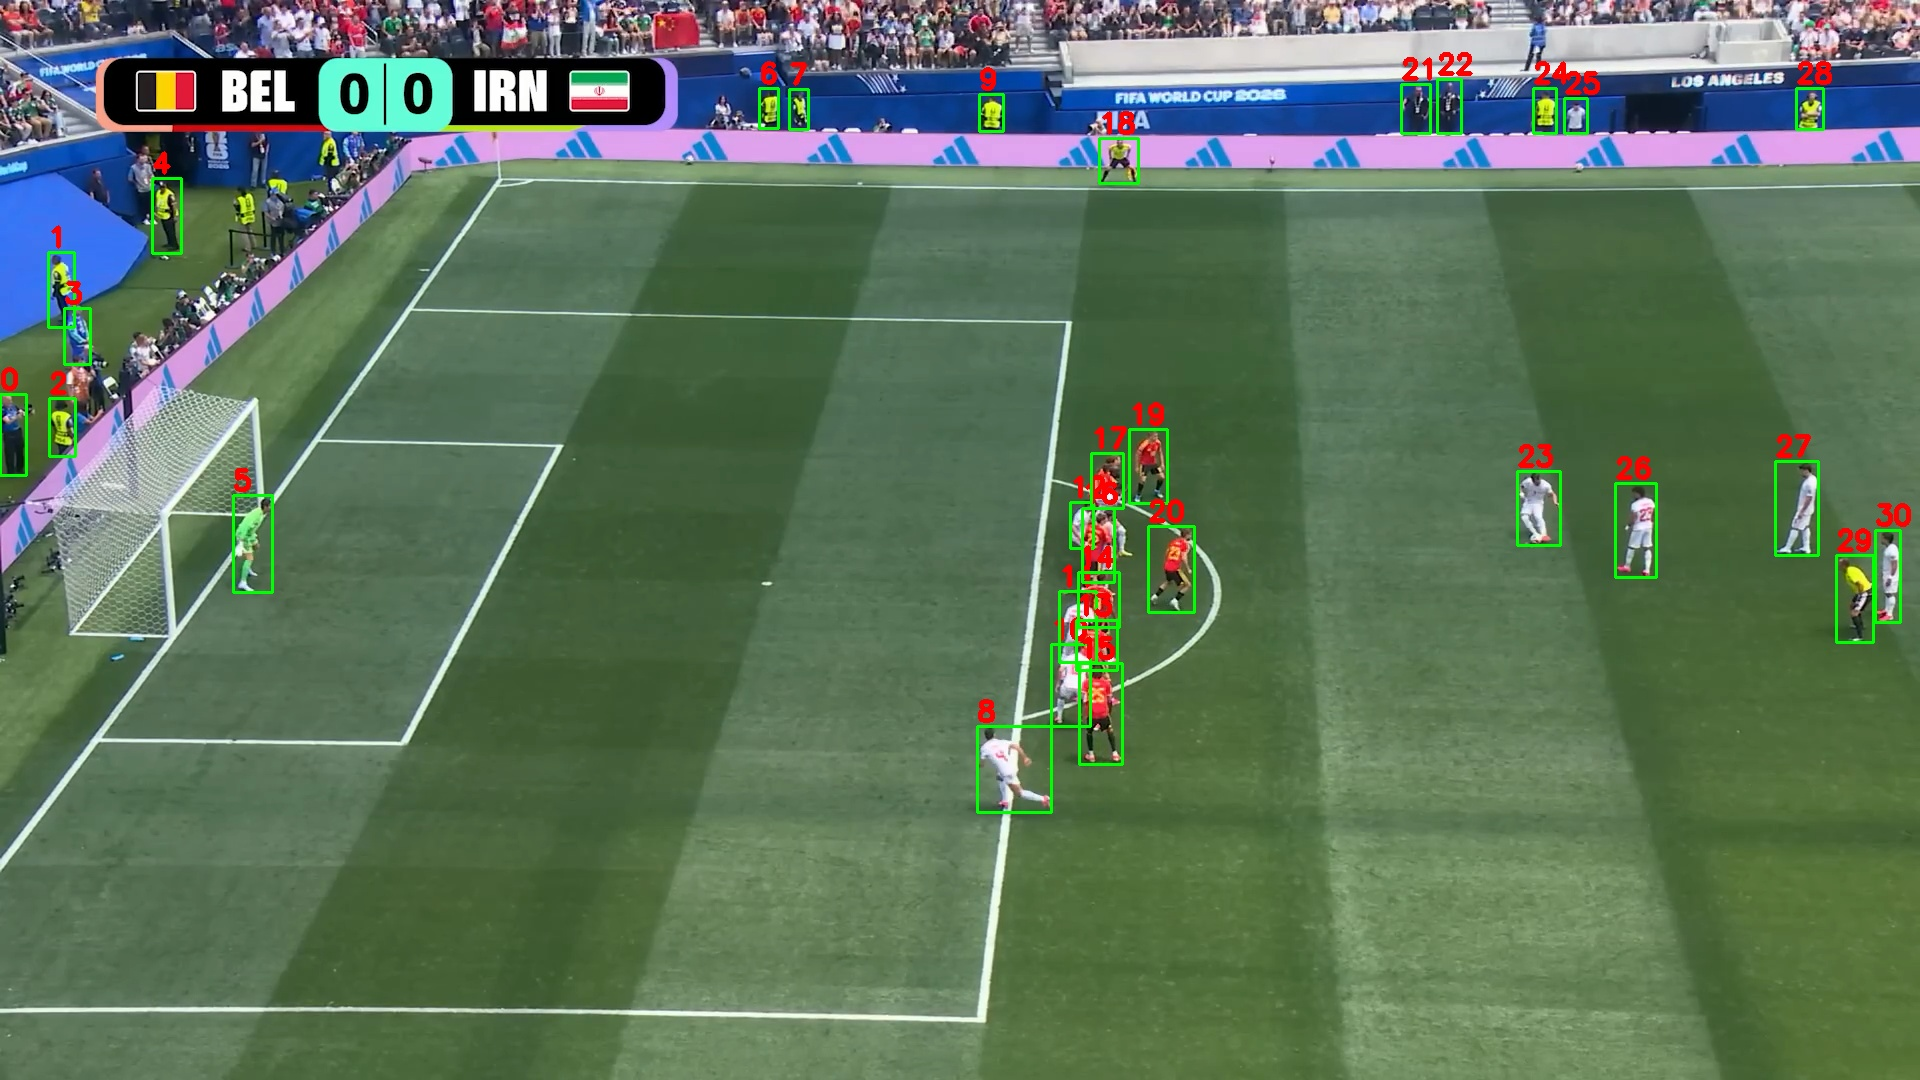

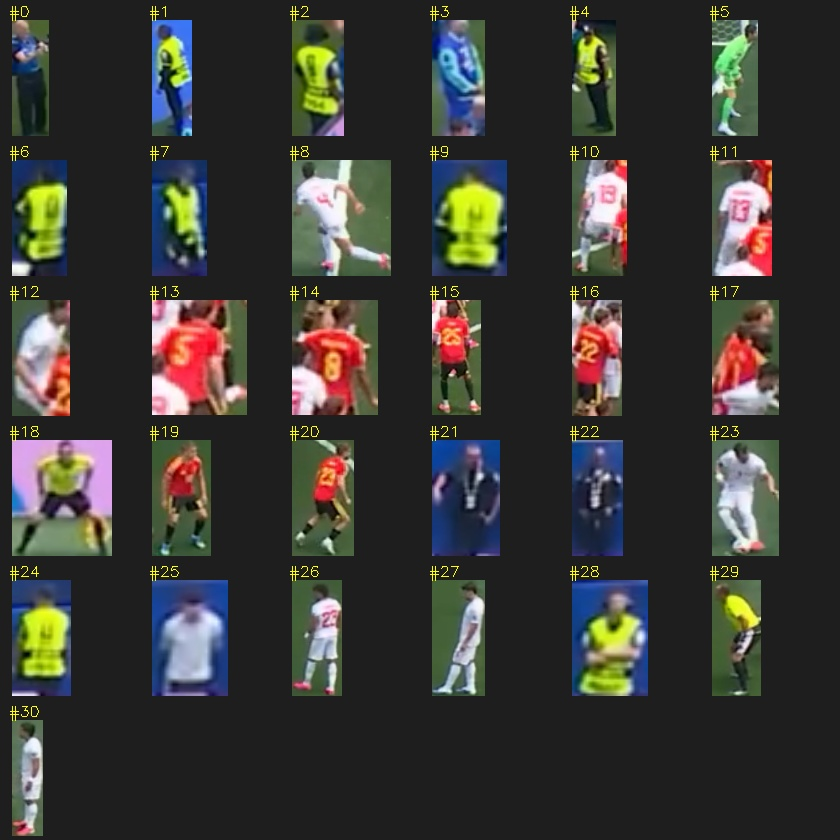

In [8]:
import math
from IPython.display import Image, display

def get_box(p):
    return [int(v) for v in np.asarray(p['bbox']).reshape(-1)[:4]]

vis = img_bgr.copy()
for i, p in enumerate(all_people):
    x1, y1, x2, y2 = get_box(p)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, str(i), (x1, max(y1-6, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 3)
cv2.imwrite(f'{OUT_DIR}/_indexed.jpg', vis)
display(Image(f'{OUT_DIR}/_indexed.jpg', width=950))

n = len(all_people); cols = min(6, n); rows = math.ceil(n/cols); cell = 140
sheet = np.full((rows*cell, cols*cell, 3), 30, np.uint8)
for i, p in enumerate(all_people):
    x1, y1, x2, y2 = get_box(p); x1, y1 = max(x1,0), max(y1,0)
    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0: continue
    h, w = crop.shape[:2]; s = min((cell-24)/max(h,1), (cell-24)/max(w,1))
    crop = cv2.resize(crop, (max(int(w*s),1), max(int(h*s),1)))
    r, c = divmod(i, cols); oy, ox = r*cell+20, c*cell+12
    sheet[oy:oy+crop.shape[0], ox:ox+crop.shape[1]] = crop
    cv2.putText(sheet, f'#{i}', (c*cell+8, r*cell+16), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)
cv2.imwrite(f'{OUT_DIR}/_thumbs.jpg', sheet)
display(Image(f'{OUT_DIR}/_thumbs.jpg', width=min(cols*140, 900)))

In [9]:
import ipywidgets as W
try:
    from google.colab import output as _co; _co.enable_custom_widget_manager()
except Exception:
    pass

SELECTED_IDXS = []
_b = [W.Checkbox(value=False, description=f'#{i}', indent=False, layout=W.Layout(width='90px')) for i in range(len(all_people))]
_btn = W.Button(description='Confirm selection', button_style='success'); _out = W.Output()
def _confirm(_):
    global SELECTED_IDXS
    SELECTED_IDXS = [i for i, b in enumerate(_b) if b.value]
    with _out: _out.clear_output(); print('Selected:', SELECTED_IDXS or '(none)')
_btn.on_click(_confirm)
display(W.VBox([W.GridBox(_b, layout=W.Layout(grid_template_columns='repeat(6, 90px)')), _btn, _out]))

In [ ]:
# SELECTED_IDXS = [0, 1, 2]   # <-- manual fallback
assert SELECTED_IDXS, 'No players selected.'
print('Working with players:', SELECTED_IDXS)

## 4. Pitch homography

Pair ≥4 image points with known pitch landmarks (metres). World frame: origin at a corner, **X along length (0→105), Y across (0→68)**. Use the grid overlay to read pixel coords.

In [12]:
import base64, numpy as np, cv2
from google.colab.output import eval_js
from IPython.display import Image, display

def click_points(image_bgr, num_points, max_w=1000, pair_lines=True):
    """Click num_points on the image; returns Nx2 array in ORIGINAL pixel coords.
    Points are collected in order; if pair_lines, each consecutive pair is drawn as a line."""
    _, buf = cv2.imencode('.png', image_bgr)
    src = 'data:image/png;base64,' + base64.b64encode(buf).decode()
    js = '''
    (async function() {
      const src="__SRC__", N=__N__, maxW=__W__, pairLines=__PAIR__;
      const img=new Image(); await new Promise(r=>{img.onload=r; img.src=src;});
      const s=Math.min(1, maxW/img.width);
      const cv=document.createElement('canvas'); cv.width=img.width*s; cv.height=img.height*s;
      const ctx=cv.getContext('2d'); ctx.drawImage(img,0,0,cv.width,cv.height); cv.style.cursor='crosshair';
      const info=document.createElement('div'); info.style.cssText='color:#0f0;font:14px monospace;padding:4px';
      info.textContent='0 / '+N;
      const wrap=document.createElement('div'); wrap.appendChild(cv); wrap.appendChild(info); document.body.appendChild(wrap);
      const pts=[], cols=['#ff3b30','#34c759','#ffcc00','#0a84ff','#bf5af2','#5ac8fa'];
      cv.onclick=(e)=>{const r=cv.getBoundingClientRect(); const x=e.clientX-r.left, y=e.clientY-r.top;
        pts.push([x/s,y/s]); const c=cols[Math.floor((pts.length-1)/2)%cols.length];
        ctx.fillStyle=c; ctx.strokeStyle=c; ctx.beginPath(); ctx.arc(x,y,4,0,7); ctx.fill();
        ctx.font='14px monospace'; ctx.fillText(String(pts.length-1),x+6,y-6);
        if(pairLines && pts.length%2===0){const a=pts[pts.length-2],b=pts[pts.length-1];
          ctx.lineWidth=2; ctx.beginPath(); ctx.moveTo(a[0]*s,a[1]*s); ctx.lineTo(b[0]*s,b[1]*s); ctx.stroke();}
        info.textContent=pts.length+' / '+N;};
      await new Promise(res=>{const t=setInterval(()=>{if(pts.length>=N){clearInterval(t); res();}},100);});
      cv.onclick=null; info.textContent='done ('+N+' points)'; return pts;
    })()
    '''
    js = (js.replace('__SRC__', src).replace('__N__', str(num_points))
            .replace('__W__', str(max_w)).replace('__PAIR__', 'true' if pair_lines else 'false'))
    return np.array(eval_js(js), dtype=np.float32)

# Click 4 points = 2 lines parallel to the goal line.
# Order: line1 = pts 0,1  |  line2 = pts 2,3.  Pick the two lines FAR APART.
LINE_PTS = click_points(img_bgr, 4)
print('clicked:\n', LINE_PTS)

def line_through(p, q):
    return np.cross([p[0], p[1], 1.0], [q[0], q[1], 1.0])

l1, l2 = line_through(*LINE_PTS[:2]), line_through(*LINE_PTS[2:])
vp = np.cross(l1, l2)
VP_INF = abs(vp[2]) < 1e-9
if VP_INF:
    VP_DIR = np.array([vp[0], vp[1]], float); VP_DIR /= np.linalg.norm(VP_DIR)
    print('Lines ~parallel in image -> vanishing point at infinity, direction', VP_DIR)
else:
    vp = vp / vp[2]
    print('Vanishing point (px):', vp[:2].round(1))

clicked:
 [[ 981.12 1015.68]
 [1067.52  320.64]
 [  94.08  737.28]
 [ 497.28  176.64]]
Vanishing point (px): [1208.3 -812. ]


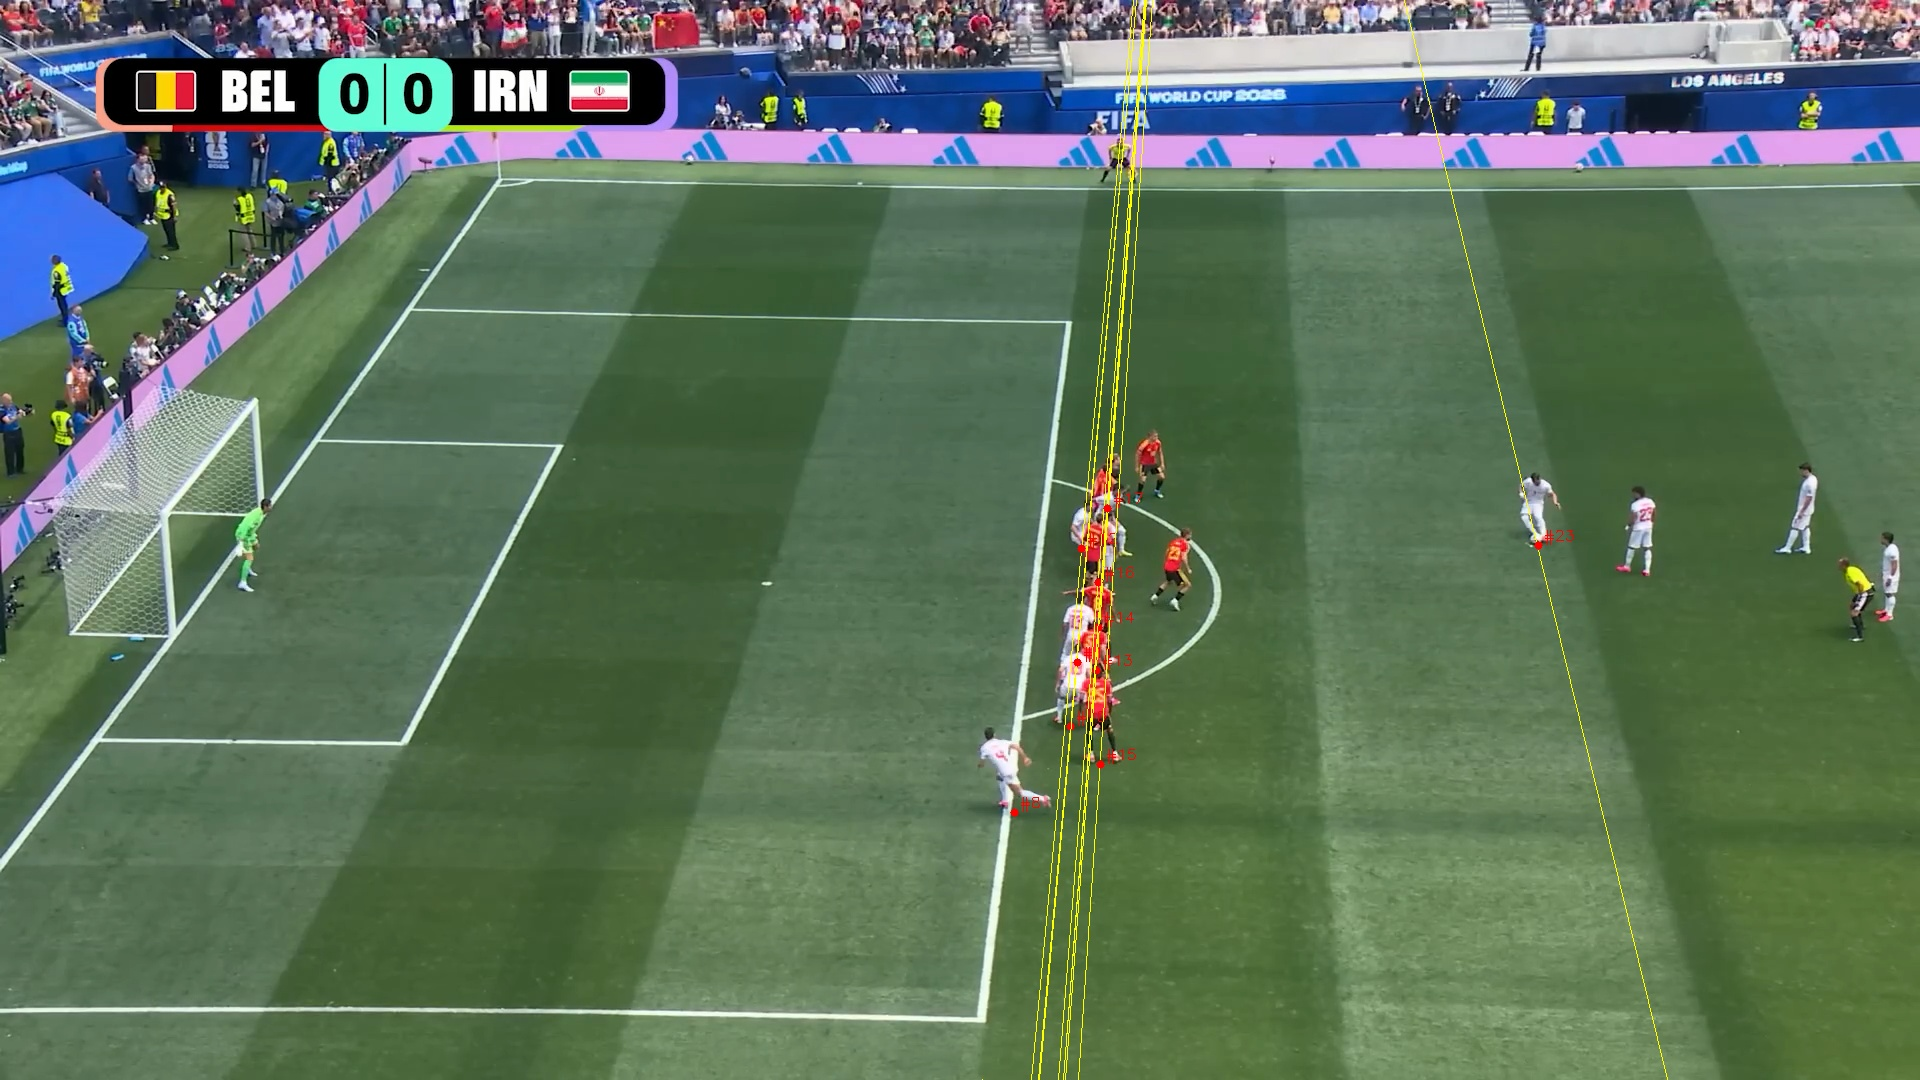

In [13]:
def parallel_line_through(pt):
    """World-line parallel to the goal line, through image point pt -> homogeneous line."""
    if VP_INF:
        return np.cross([pt[0], pt[1], 1.0], [pt[0]+VP_DIR[0], pt[1]+VP_DIR[1], 1.0])
    return np.cross([vp[0], vp[1], 1.0], [pt[0], pt[1], 1.0])

def draw_line(img, line, color=(0,255,255), thick=2):
    h, w = img.shape[:2]; a, b, c = line; cand = []
    if abs(b) > 1e-6:
        for x in (0, w-1): cand.append((x, -(a*x+c)/b))
    if abs(a) > 1e-6:
        for y in (0, h-1): cand.append((-(b*y+c)/a, y))
    cand = [(int(x), int(y)) for x, y in cand if -1e4 < x < 1e4 and -1e4 < y < 1e4]
    if len(cand) >= 2:
        ok, p1, p2 = cv2.clipLine((0, 0, w, h), cand[0], cand[-1])
        if ok: cv2.line(img, p1, p2, color, thick)

# Demo: a parallel line through each selected player's feet
demo = img_bgr.copy()
for i in SELECTED_IDXS:
    x1, y1, x2, y2 = [int(v) for v in np.asarray(all_people[i]['bbox']).reshape(-1)[:4]]
    foot = ((x1+x2)//2, y2)
    draw_line(demo, parallel_line_through(foot), (0,255,255), 1)
    cv2.circle(demo, foot, 4, (0,0,255), -1)
    cv2.putText(demo, f'#{i}', (foot[0]+5, foot[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
cv2.imwrite(f'{OUT_DIR}/parallel_lines.jpg', demo)
display(Image(f'{OUT_DIR}/parallel_lines.jpg', width=1000))

## 5. Reconstruct selected (overlay + mesh export)

2D overlay of just the selected players, plus an `.obj` per player.

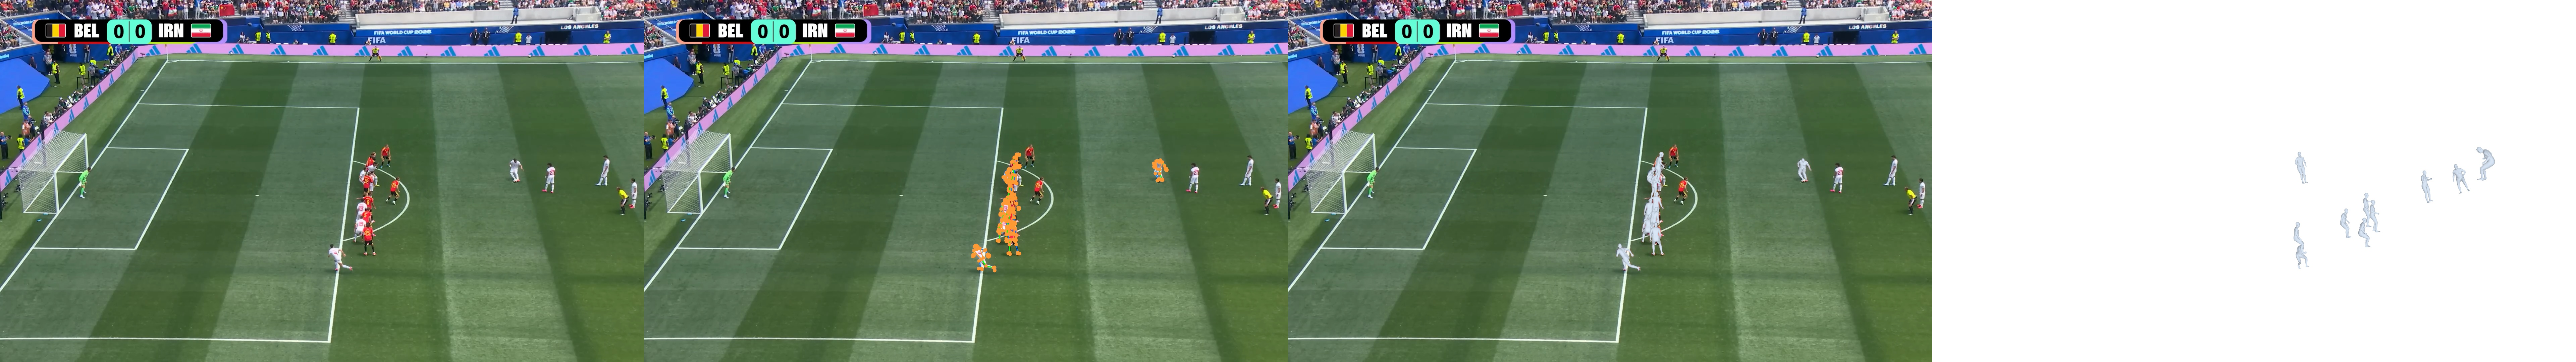

Meshes written to /content/scene_out


In [14]:
selected = [all_people[i] for i in SELECTED_IDXS]
rend = visualize_sample_together(img_bgr, selected, FACES)
cv2.imwrite(f'{OUT_DIR}/selected_overlay.jpg', rend.astype(np.uint8))
display(Image(f'{OUT_DIR}/selected_overlay.jpg', width=950))

def write_obj(path, verts, faces):
    with open(path, 'w') as f:
        for v in verts: f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n')
        for t in faces: f.write(f'f {t[0]+1} {t[1]+1} {t[2]+1}\n')

for i, p in zip(SELECTED_IDXS, selected):
    write_obj(f'{OUT_DIR}/person_{i:02d}.obj', np.asarray(p['pred_vertices']), FACES)
print('Meshes written to', OUT_DIR)

## 6. Place players in a 3D scene

Tie the meshes to the pitch: recover camera pose from the homography points + 3DB's focal length (`solvePnP`), rotate each mesh into the pitch frame, and **anchor each by its feet** to the homography ground position (cancels monocular depth error). The pitch is the Z=0 plane, +Z up.

**If players look upside-down or sunk into the turf, set `FLIP_Z = True` and re-run.**

In [16]:
FLIP_Z = False   # toggle if orientation is wrong

# ground contact in image (bbox bottom-centre) -> pitch (X,Y)
def ground_xy(person):
    x1, y1, x2, y2 = np.asarray(person['bbox']).reshape(-1)[:4]
    return img_to_world(np.array([[(x1+x2)/2.0, y2]], np.float32))[0]

# camera pose from the clicked pitch points (ground plane, Z=0) + focal length
f = float(selected[0]['focal_length'])
h_img, w_img = img_bgr.shape[:2]
K = np.array([[f,0,w_img/2],[0,f,h_img/2],[0,0,1]], np.float32)
obj_pts = np.c_[world_pts, np.zeros(len(world_pts))].astype(np.float32)
ok, rvec, tvec = cv2.solvePnP(obj_pts, img_pts, K, None, flags=cv2.SOLVEPNP_ITERATIVE)
R, _ = cv2.Rodrigues(rvec)
Rcw = R.T   # camera-frame rotation -> world frame

def place_mesh(person):
    V = np.asarray(person['pred_vertices'], dtype=np.float64)
    Vw = (Rcw @ V.T).T                       # rotate into pitch orientation
    if FLIP_Z: Vw[:, 2] *= -1
    # foot reference = centroid of lowest 1% of vertices by height
    k = max(int(0.01 * len(Vw)), 1)
    foot = Vw[np.argsort(Vw[:, 2])[:k]].mean(axis=0)
    fx, fy = ground_xy(person)
    Vw[:, 0] += fx - foot[0]
    Vw[:, 1] += fy - foot[1]
    Vw[:, 2] += -Vw[:, 2].min()              # drop feet to Z=0
    return Vw

placed = {i: place_mesh(all_people[i]) for i in SELECTED_IDXS}
med_h = np.median([v[:, 2].max() for v in placed.values()])
print(f'median placed player height: {med_h:.2f} m  (expect ~1.6–2.0 m)')
if med_h < 0.5:
    print('>>> Heights look wrong — try FLIP_Z = True and re-run this cell.')

AssertionError: Label players in TEAM as att/def first.

In [ ]:
import plotly.graph_objects as go

def pitch_lines():
    L, Wd = PITCH_L, PITCH_W; segs = []
    segs += [([0,L,L,0,0],[0,0,Wd,Wd,0])]                 # boundary
    segs += [([L/2,L/2],[0,Wd])]                          # halfway
    for gx, s in [(0,1),(L,-1)]:
        segs += [([gx, gx+s*16.5, gx+s*16.5, gx],
                  [(Wd-40.32)/2,(Wd-40.32)/2,(Wd+40.32)/2,(Wd+40.32)/2])]
    th = np.linspace(0, 2*np.pi, 60)
    segs += [(L/2+9.15*np.cos(th), Wd/2+9.15*np.sin(th))]  # centre circle
    traces = []
    for xs, ys in segs:
        traces.append(go.Scatter3d(x=list(xs), y=list(ys), z=[0]*len(xs),
                                   mode='lines', line=dict(color='white', width=4),
                                   showlegend=False))
    return traces

fig = go.Figure()
# green pitch surface
fig.add_trace(go.Mesh3d(x=[0,PITCH_L,PITCH_L,0], y=[0,0,PITCH_W,PITCH_W], z=[0,0,0,0],
                        i=[0,0], j=[1,2], k=[2,3], color='seagreen', opacity=0.55, showlegend=False))
for t in pitch_lines(): fig.add_trace(t)
# player meshes
palette = ['crimson','royalblue','gold','darkorange','mediumpurple','deepskyblue']
for n, (i, Vw) in enumerate(placed.items()):
    fig.add_trace(go.Mesh3d(x=Vw[:,0], y=Vw[:,1], z=Vw[:,2],
                            i=FACES[:,0], j=FACES[:,1], k=FACES[:,2],
                            color=palette[n % len(palette)], opacity=1.0, name=f'#{i}'))
fig.update_layout(scene=dict(aspectmode='data',
                             xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)'),
                  margin=dict(l=0,r=0,t=0,b=0), height=650)
fig.show()

### (optional) export the whole scene to GLB for Blender

In [ ]:
import trimesh
scene = trimesh.Scene()
ground = trimesh.creation.box(extents=[PITCH_L, PITCH_W, 0.02])
ground.apply_translation([PITCH_L/2, PITCH_W/2, -0.01])
ground.visual.face_colors = [40, 140, 70, 255]
scene.add_geometry(ground, node_name='pitch')
for i, Vw in placed.items():
    scene.add_geometry(trimesh.Trimesh(vertices=Vw, faces=FACES, process=False), node_name=f'player_{i}')
glb_path = f'{OUT_DIR}/pitch_scene.glb'
scene.export(glb_path)
print('exported', glb_path)